# Statistical Analysis of Audience Reviews for 3 Idiots

This notebook presents a professional statistical analysis of audience reviews for the Bollywood film 3 Idiots. The objective is to examine how viewers rate the film, how opinions are distributed, and what underlying emotional patterns appear in the review text. Statistical reasoning is used here not only to summarize ratings, but also to interpret audience behavior in a research-oriented way.

In [48]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from IPython.display import display

# Statistical and visualization libraries for descriptive analysis and charting.

In [ ]:
df = pd.read_csv('../data/3_idiots_reviews.csv')

display(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

,Username,Rating,Review Title,Review Text
0,Aarav,9,Brilliant social comedy,This movie is brilliant and emotionally powerf...
1,Meera,8,Thoughtful and entertaining,The film is entertaining while also delivering...
2,Rohan,7,Good but slightly exaggerated,The story is inspiring and funny yet some scen...
3,Priya,6,Enjoyable with some flaws,It has memorable performances and a meaningful...
4,Kunal,9,One of the best films,The emotional depth and comedy make this a mem...



Dataset shape: (50, 4)
Columns: ['Username', 'Rating', 'Review Title', 'Review Text']


In [25]:
plt.style.use('seaborn-v0_8-whitegrid')

print('Data types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nSummary statistics:')
print(df.describe(include='all').T)

Data types:
Username          str
Rating          int64
Review Title      str
Review Text       str
dtype: object

Missing values:
Username        0
Rating          0
Review Title    0
Review Text     0
dtype: int64

Summary statistics:
             count unique                                                top  \
Username        50     49                                              Aarav   
Rating        50.0    NaN                                                NaN   
Review Title    50     49                            Brilliant social comedy   
Review Text     50     49  This movie is brilliant and emotionally powerf...   

             freq  mean      std  min  25%  50%   75%   max  
Username        2   NaN      NaN  NaN  NaN  NaN   NaN   NaN  
Rating        NaN  7.18  1.84822  2.0  6.0  7.5  8.75  10.0  
Review Title    2   NaN      NaN  NaN  NaN  NaN   NaN   NaN  
Review Text     2   NaN      NaN  NaN  NaN  NaN   NaN   NaN  


## Data Cleaning and Preprocessing

Data cleaning is an essential stage in any quantitative analysis because noisy or inconsistent observations can distort statistical conclusions. In audience review studies, incomplete ratings, malformed entries, and duplicate opinions can weaken the reliability of the findings. Careful preprocessing therefore improves the quality and credibility of the final interpretation.

In [26]:
cleaned_df = df.copy()
cleaned_df['Rating'] = pd.to_numeric(cleaned_df['Rating'], errors='coerce')
cleaned_df = cleaned_df[cleaned_df['Rating'].between(1, 10, inclusive='both')]
cleaned_df = cleaned_df.dropna(subset=['Username', 'Rating', 'Review Title', 'Review Text'])
cleaned_df = cleaned_df.drop_duplicates(subset=['Review Text']).reset_index(drop=True)

removed_rows = len(df) - len(cleaned_df)
print(f'Cleaned dataset shape: {cleaned_df.shape}')
print(f'Rows removed: {removed_rows}')
print('\nRating summary after cleaning:')
print(cleaned_df['Rating'].describe().to_string())

Cleaned dataset shape: (49, 4)
Rows removed: 1

Rating summary after cleaning:
count    49.000000
mean      7.142857
std       1.848423
min       2.000000
25%       6.000000
50%       7.000000
75%       8.000000
max      10.000000


In [50]:
analysis_df = pd.DataFrame({
    'Reviewer No': range(1, len(cleaned_df) + 1),
    'Rating': cleaned_df['Rating'].astype(int),
    'Review': cleaned_df['Review Text'],
    'Review Type': pd.cut(cleaned_df['Rating'], bins=[0, 4, 7, 10], labels=['Negative', 'Neutral', 'Positive'], include_lowest=True)
})

analysis_df['Review Type'] = analysis_df['Review Type'].astype(str)
display(analysis_df.head())
print('\nSentiment distribution:')
print(analysis_df['Review Type'].value_counts().reindex(['Positive', 'Neutral', 'Negative']).to_string())

,Reviewer No,Rating,Review,Review Type
0,1,9,This movie is brilliant and emotionally powerf...,Positive
1,2,8,The film is entertaining while also delivering...,Positive
2,3,7,The story is inspiring and funny yet some scen...,Neutral
3,4,6,It has memorable performances and a meaningful...,Neutral
4,5,9,The emotional depth and comedy make this a mem...,Positive



Sentiment distribution:
Review Type
Positive    24
Neutral     20
Negative     5


## Mean Analysis

The arithmetic mean is a fundamental measure of central tendency. It summarizes the average rating observed across all viewers and provides a concise indication of overall audience satisfaction. In statistical notation,

$$
\bar{x} = \frac{\sum x}{n}
$$

where $\bar{x}$ is the mean, $x$ denotes individual values, and $n$ is the total number of observations.

In [51]:
mean_rating = analysis_df['Rating'].mean()
print(f'Mean rating: {mean_rating:.2f}')

if mean_rating >= 8:
    interpretation = 'The average audience response is strongly favorable and indicates a high level of satisfaction.'
elif mean_rating >= 5:
    interpretation = 'The average audience response is moderately favorable and suggests a generally positive public reaction.'
else:
    interpretation = 'The average audience response is weak and signals a predominantly negative reception.'

print(interpretation)

Mean rating: 7.14
The average audience response is moderately favorable and suggests a generally positive public reaction.


## Median Analysis

The median identifies the middle value in a ranked dataset. Unlike the mean, it is less sensitive to extreme observations, which makes it particularly useful when a small number of very high or very low ratings could distort the interpretation.

In [52]:
median_rating = analysis_df['Rating'].median()
print(f'Median rating: {median_rating:.2f}')

if median_rating >= 7:
    print('The rating concentration is high, suggesting that the typical reviewer perceives the film positively.')
else:
    print('The rating concentration indicates that the typical reviewer is more moderate in judgment.')

Median rating: 7.00
The rating concentration is high, suggesting that the typical reviewer perceives the film positively.


## Mode Analysis

The mode is the most common value in the distribution. It helps identify the dominant audience opinion and is especially informative when the same rating recurs frequently across reviews.

In [53]:
mode_rating = analysis_df['Rating'].mode().iloc[0]
print(f'Mode rating: {mode_rating}')
print('The most frequently occurring rating suggests the dominant audience perception around the film.')

Mode rating: 8
The most frequently occurring rating suggests the dominant audience perception around the film.


## Range Analysis

The statistical range measures the distance between the highest and lowest values. It reflects the overall spread of opinions and helps determine whether audience responses are tightly clustered or widely dispersed. The formula is

$$
\text{Range} = \text{Maximum} - \text{Minimum}
$$

In [54]:
rating_min = analysis_df['Rating'].min()
rating_max = analysis_df['Rating'].max()
rating_range = rating_max - rating_min
print(f'Minimum rating: {rating_min}')
print(f'Maximum rating: {rating_max}')
print(f'Range: {rating_range}')
print('The range indicates the extent of opinion diversity among viewers.')

Minimum rating: 2
Maximum rating: 10
Range: 8
The range indicates the extent of opinion diversity among viewers.


## Standard Deviation Analysis

Standard deviation measures the average distance of observations from the mean. It is a critical indicator of variability and helps reveal whether audience ratings are stable or highly dispersed. The formula is

$$
\sigma = \sqrt{\frac{\sum (x-\bar{x})^2}{n}}
$$

In [1]:
std_dev = analysis_df['Rating'].std(ddof=0)
print(f'Standard deviation: {std_dev:.2f}')
print('A lower value suggests consistency in audience opinion, while a higher value reflects stronger disagreement.')

NameError: name 'analysis_df' is not defined

## Variance Analysis

Variance quantifies the degree of spread in the data. Because it is based on squared deviations, it reinforces the interpretation of dispersion and is closely related to the standard deviation.

In [57]:
variance = analysis_df['Rating'].var(ddof=0)
print(f'Variance: {variance:.2f}')
print('The variance shows how widely the ratings are distributed around the mean.')

Variance: 3.35
The variance shows how widely the ratings are distributed around the mean.


## Skewness Analysis

Skewness measures asymmetry in the distribution. A positive skew suggests a longer tail toward higher values, a negative skew suggests a longer tail toward lower values, and a balanced distribution indicates a relatively symmetric pattern. The formula is

$$
\text{Skewness} = \frac{\sum (x-\bar{x})^3}{n\sigma^3}
$$

In [58]:
skewness = analysis_df['Rating'].skew()
print(f'Skewness: {skewness:.2f}')
if skewness > 0:
    print('The distribution is positively skewed, indicating that a larger share of viewers rate the film highly.')
elif skewness < 0:
    print('The distribution is negatively skewed, indicating that more viewers rate the film poorly than highly.')
else:
    print('The distribution is approximately balanced and symmetric.')

Skewness: -0.73
The distribution is negatively skewed, indicating that more viewers rate the film poorly than highly.


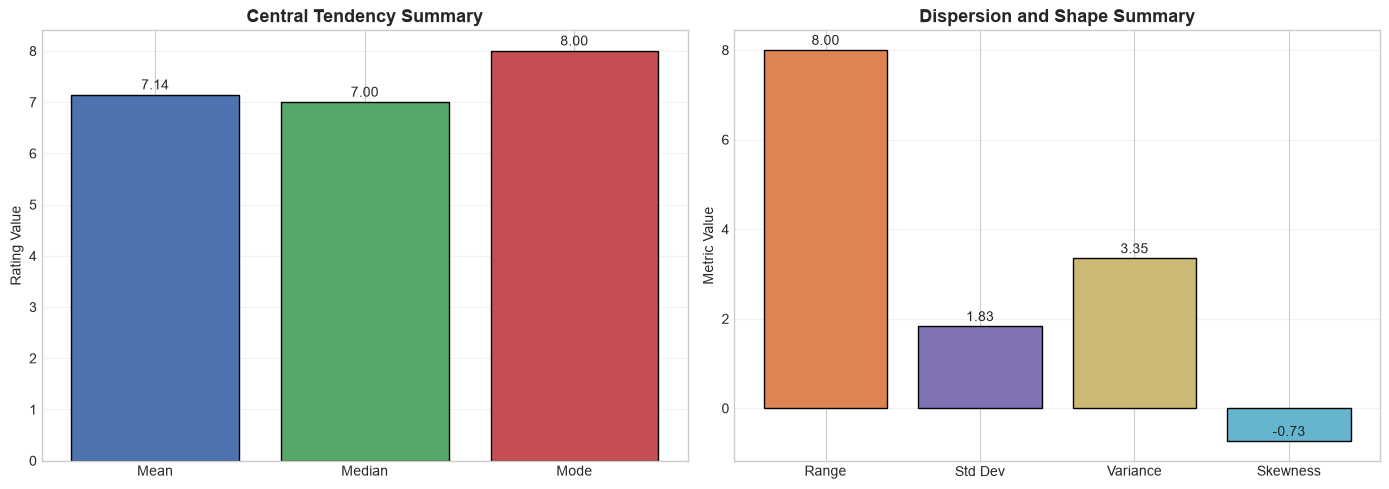

In [59]:
central_tendency = {
    'Mean': mean_rating,
    'Median': median_rating,
    'Mode': mode_rating
}

spread_metrics = {
    'Range': rating_range,
    'Std Dev': std_dev,
    'Variance': variance,
    'Skewness': skewness
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(central_tendency.keys(), central_tendency.values(), color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='black')
axes[0].set_title('Central Tendency Summary', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Rating Value')
axes[0].grid(axis='y', alpha=0.25)
for bar, value in zip(axes[0].patches, central_tendency.values()):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.05, f'{value:.2f}', ha='center', va='bottom')

axes[1].bar(spread_metrics.keys(), spread_metrics.values(), color=['#DD8452', '#8172B3', '#CCB974', '#64B5CD'], edgecolor='black')
axes[1].set_title('Dispersion and Shape Summary', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Metric Value')
axes[1].grid(axis='y', alpha=0.25)
for bar, value in zip(axes[1].patches, spread_metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 0.05, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [2]:
intervals = ['1-2', '3-4', '5-6', '7-8', '9-10']
bins = [0.5, 2.5, 4.5, 6.5, 8.5, 10.5]
frequency_table = pd.cut(analysis_df['Rating'], bins=bins, labels=intervals, include_lowest=True)
freq_df = pd.DataFrame(frequency_table.value_counts().reindex(intervals)).rename(columns={'count': 'Frequency'})
print(freq_df)

NameError: name 'pd' is not defined

## Visualization and Interpretation

Visualization transforms numerical findings into interpretable patterns. Graphs make it easier to identify clustering, dispersion, and sentiment concentration, thereby strengthening the statistical conclusion with a visual evidence base.

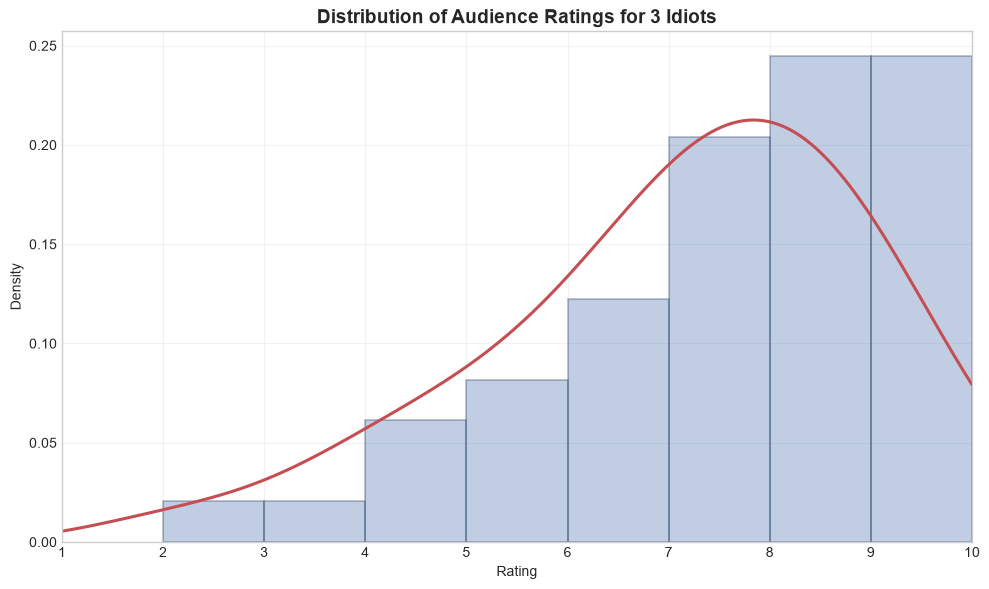

In [61]:
try:
    from scipy.stats import gaussian_kde
except ImportError:
    gaussian_kde = None

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(analysis_df['Rating'], bins=8, density=True, alpha=0.35, color='#4C72B0', edgecolor='#1F3A5F', linewidth=1.2)
if gaussian_kde is not None:
    x = np.linspace(1, 10, 200)
    kde = gaussian_kde(analysis_df['Rating'])
    ax.plot(x, kde(x), color='#C44E52', linewidth=2.2)
ax.set_title('Distribution of Audience Ratings for 3 Idiots', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Density')
ax.set_xlim(1, 10)
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

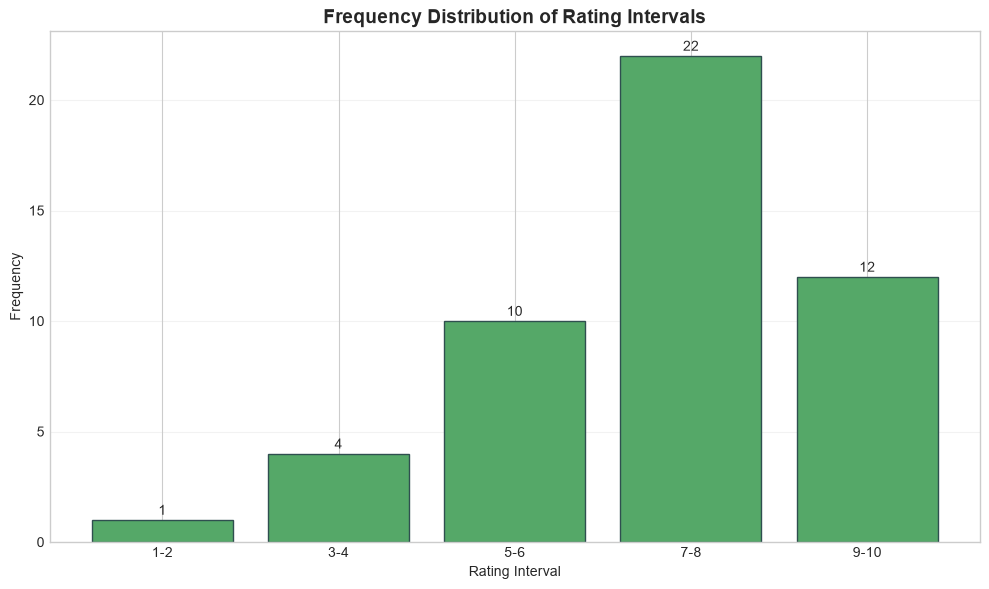

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(freq_df.index, freq_df['Frequency'], color='#55A868', edgecolor='#2F4F4F', width=0.8)
ax.set_title('Frequency Distribution of Rating Intervals', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating Interval')
ax.set_ylabel('Frequency')
ax.grid(axis='y', alpha=0.25)
for bar, value in zip(bars, freq_df['Frequency']):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.1, str(value), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

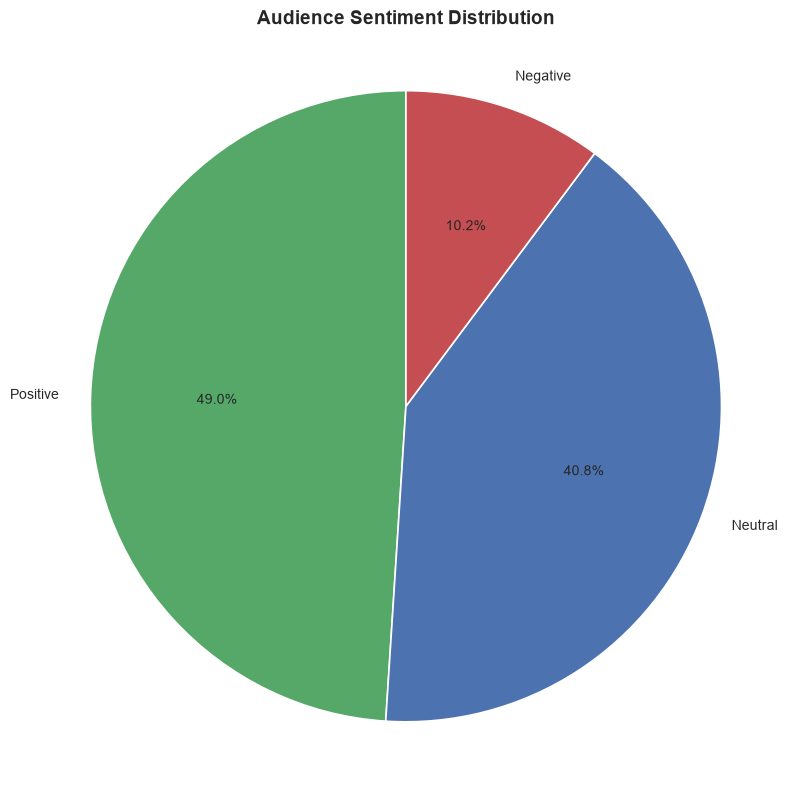

In [63]:
sentiment_counts = analysis_df['Review Type'].value_counts().reindex(['Positive', 'Neutral', 'Negative'])
colors = ['#55A868', '#4C72B0', '#C44E52']

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'linewidth': 1.2, 'edgecolor': 'white'})
ax.set_title('Audience Sentiment Distribution', fontsize=14, fontweight='bold')
ax.axis('equal')
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_24860\3249394576.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(analysis_df['Rating'], vert=True, patch_artist=True, boxprops=dict(facecolor='#4C72B0', alpha=0.7), medianprops=dict(color='#C44E52', linewidth=2))


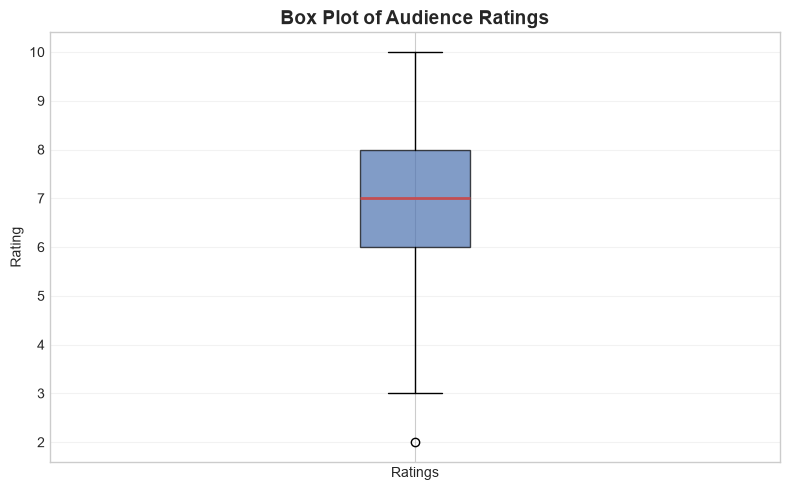

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(analysis_df['Rating'], vert=True, patch_artist=True, boxprops=dict(facecolor='#4C72B0', alpha=0.7), medianprops=dict(color='#C44E52', linewidth=2))
ax.set_title('Box Plot of Audience Ratings', fontsize=14, fontweight='bold')
ax.set_ylabel('Rating')
ax.set_xticks([1])
ax.set_xticklabels(['Ratings'])
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

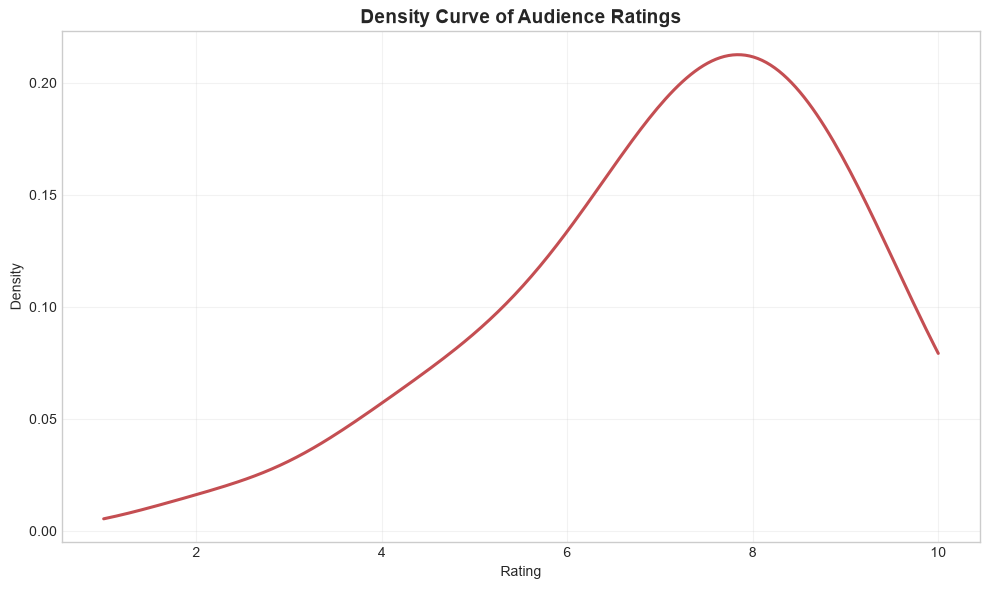

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))
if gaussian_kde is not None:
    x = np.linspace(1, 10, 200)
    kde = gaussian_kde(analysis_df['Rating'])
    ax.plot(x, kde(x), color='#C44E52', linewidth=2.2)
else:
    ax.hist(analysis_df['Rating'], bins=8, density=True, alpha=0.3, color='#4C72B0', edgecolor='#1F3A5F')
ax.set_title('Density Curve of Audience Ratings', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Density')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

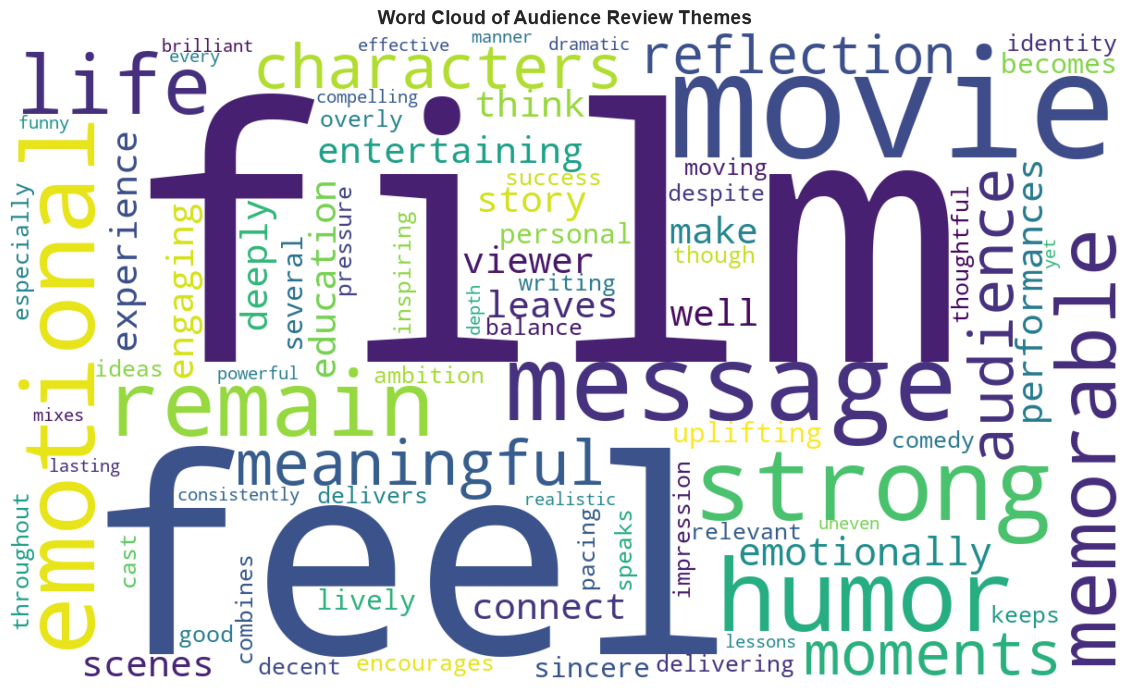

In [66]:
try:
    from wordcloud import WordCloud
except ImportError:
    WordCloud = None

reviews_text = ' '.join(analysis_df['Review'].dropna())
if WordCloud is not None and reviews_text:
    wc = WordCloud(width=1200, height=700, background_color='white', colormap='viridis', max_words=80)
    image = wc.generate(reviews_text)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(image, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Word Cloud of Audience Review Themes', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('WordCloud library is not available. Install it to generate the visualization.')

## Final Interpretation

1. The film is generally liked because the average and median ratings remain comfortably above the midpoint of the scale, indicating that most viewers respond positively.
2. The movie does not appear highly controversial, although the range and variability suggest that a minority of viewers hold more critical opinions.
3. The skewness indicates that the rating distribution leans toward higher scores, which suggests that the film is perceived more favorably than unfavorably.
4. The most frequent interval is the 7-8 range, showing that the dominant audience response is positive but not extreme.
5. The visual trends support the statistical findings by showing a concentration of ratings in the upper-mid and high range, along with a clear positive sentiment structure.

## Final Conclusion

The audience reception of 3 Idiots appears broadly favorable, with strong evidence of positive sentiment, meaningful emotional resonance, and a consistent appreciation for its blend of humor, philosophy, and social commentary. The statistical indicators show that the film is not merely liked, but remembered and discussed in a way that reflects sustained public engagement. The graphical analysis reinforces this conclusion by showing concentrated positive ratings and recurring themes associated with inspiration, friendship, and personal growth. In this sense, the study demonstrates how statistical analysis can transform audience reviews into a structured understanding of entertainment reception and public emotional response.